# Retail Demand Forecasting
## Data Cleaning and Initial EDA

This notebook focuses on understanding and preparing the retail sales data
and performing an initial exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "../data/raw/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")
stores = pd.read_csv(DATA_PATH + "stores.csv")
transactions = pd.read_csv(DATA_PATH + "transactions.csv")
holidays = pd.read_csv(DATA_PATH + "holidays_events.csv")
oil = pd.read_csv(DATA_PATH + "oil.csv")

In [3]:
datasets = {
    "train": train,
    "test": test,
    "stores": stores,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

train: (3000888, 6)
test: (28512, 5)
stores: (54, 5)
transactions: (83488, 3)
holidays: (350, 6)
oil: (1218, 2)


In [4]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


TRAIN


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



TEST


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0



STORES


...

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



HOLIDAYS


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



OIL


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [5]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.dtypes)


TRAIN


id               int64
date               str
store_nbr        int64
family             str
sales          float64
onpromotion      int64
dtype: object


TEST


id             int64
date             str
store_nbr      int64
family           str
onpromotion    int64
dtype: object


STORES


...

date              str
store_nbr       int64
transactions    int64
dtype: object


HOLIDAYS


date            str
type            str
locale          str
locale_name     str
description     str
transferred    bool
dtype: object


OIL


date              str
dcoilwtico    float64
dtype: object

In [6]:
date_columns = {
    "train": train,
    "test": test,
    "transactions": transactions,
    "holidays": holidays,
    "oil": oil
}

for name, df in date_columns.items():
    df["date"] = pd.to_datetime(df["date"])

In [7]:
train["date"].min(), train["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

In [8]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    display(missing)


TRAIN


Series([], dtype: int64)


TEST


Series([], dtype: int64)


STORES


...

Series([], dtype: int64)


HOLIDAYS


Series([], dtype: int64)


OIL


dcoilwtico    43
dtype: int64

In [9]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

train: 0 duplicates
test: 0 duplicates
stores: 0 duplicates
transactions: 0 duplicates
holidays: 0 duplicates
oil: 0 duplicates


In [10]:
print("Rows:", len(train))
print("Stores:", train["store_nbr"].nunique())
print("Product Families:", train["family"].nunique())
print("Start Date:", train["date"].min())
print("End Date:", train["date"].max())

Rows: 3000888
Stores: 54
Product Families: 33
Start Date: 2013-01-01 00:00:00
End Date: 2017-08-15 00:00:00


In [11]:
duplicate_keys = train.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

print("Duplicate date-store-family combinations:", duplicate_keys)

Duplicate date-store-family combinations: 0


In [12]:
train["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [13]:
print("Zero sales:", (train["sales"] == 0).sum())
print(
    "Zero sales percentage:",
    round((train["sales"] == 0).mean() * 100, 2),
    "%"
)

Zero sales: 939130
Zero sales percentage: 31.3 %


In [14]:
print("Negative sales:", (train["sales"] < 0).sum())

Negative sales: 0


In [15]:
print(
    "Rows with promotion:",
    round((train["onpromotion"] > 0).mean() * 100, 2),
    "%"
)

Rows with promotion: 20.37 %


In [16]:
oil[oil["dcoilwtico"].isna()]

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


In [17]:
oil_missing_dates = oil.loc[
    oil["dcoilwtico"].isna(), "date"
]

holidays[holidays["date"].isin(oil_missing_dates)][
    ["date", "type", "locale", "description"]
]

,date,type,locale,description
41,2013-01-01,Holiday,National,Primer dia del ano
89,2013-12-25,Holiday,National,Navidad
92,2014-01-01,Holiday,National,Primer dia del ano
99,2014-04-18,Holiday,National,Viernes Santo
120,2014-07-04,Event,National,Mundial de futbol Brasil: Cuartos de Final
155,2014-12-25,Holiday,National,Navidad
159,2015-01-01,Holiday,National,Primer dia del ano
162,2015-02-16,Holiday,National,Carnaval
166,2015-04-03,Holiday,National,Viernes Santo
179,2015-07-03,Holiday,Local,Cantonizacion de El Carmen


In [18]:
oil["dcoilwtico"] = oil["dcoilwtico"].ffill().bfill()

### Handling Missing Oil Prices

The oil dataset contains missing values in the `dcoilwtico` column, which represents the daily oil price.

During the inspection, we found 43 missing oil-price values. Several of the missing dates also appear in the holidays dataset, but not all missing dates were verified as holidays.

Since oil price is a time-dependent feature, we will not remove these rows. Instead, missing values will be imputed using forward fill, with backward fill used only when no previous value is available.

This approach preserves the dates and avoids removing observations that may be important for demand analysis.

In [19]:
oil["dcoilwtico"].isna().sum()

np.int64(0)

After imputation, we verify that no missing oil-price values remain.

### Duplicate Check

We check for duplicate rows across all datasets to ensure that duplicated observations do not affect the analysis or lead to incorrect aggregations during data integration.

In [20]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

train: 0 duplicate rows
test: 0 duplicate rows
stores: 0 duplicate rows
transactions: 0 duplicate rows
holidays: 0 duplicate rows
oil: 0 duplicate rows


### Train Data Granularity Check

The training data is expected to contain one observation for each combination of date, store, and product family. We therefore check whether any duplicate combinations exist.

In [21]:
train.duplicated(
    subset=["date", "store_nbr", "family"]
).sum()

np.int64(0)

### Date Validation

Since this project focuses on time-series demand forecasting, we verify that the date columns are correctly formatted and inspect the date ranges across the datasets.

In [22]:
for name, df in datasets.items():
    if "date" in df.columns:
        print(f"{name}: {df['date'].dtype}")

train: datetime64[us]
test: datetime64[us]
transactions: datetime64[us]
holidays: datetime64[us]
oil: datetime64[us]


In [23]:
for name, df in datasets.items():
    if "date" in df.columns:
        print(
            f"{name}: "
            f"{df['date'].min().date()} → "
            f"{df['date'].max().date()}"
        )

train: 2013-01-01 → 2017-08-15
test: 2017-08-16 → 2017-08-31
transactions: 2013-01-01 → 2017-08-15
holidays: 2012-03-02 → 2017-12-26
oil: 2013-01-01 → 2017-08-31


In [24]:
print(
    "Train unique dates:",
    train["date"].nunique()
)

print(
    "Train total rows:",
    len(train)
)

Train unique dates: 1684
Train total rows: 3000888


In [25]:
print(
    "Train date range:",
    train["date"].max() - train["date"].min()
)

Train date range: 1687 days 00:00:00


In [26]:
expected_dates = pd.date_range(
    start=train["date"].min(),
    end=train["date"].max(),
    freq="D"
)

actual_dates = train["date"].drop_duplicates().sort_values()

missing_dates = expected_dates.difference(actual_dates)

print("Expected dates:", len(expected_dates))
print("Actual dates:", len(actual_dates))
print("Missing dates:", len(missing_dates))

Expected dates: 1688
Actual dates: 1684
Missing dates: 4


In [27]:
print("Missing dates:")
for date in missing_dates:
    print(date.date())

Missing dates:
2013-12-25
2014-12-25
2015-12-25
2016-12-25


### Missing Calendar Dates

The training data contains four missing calendar dates:

- December 25, 2013
- December 25, 2014
- December 25, 2015
- December 25, 2016

All four missing dates correspond to December 25. These dates are not individual missing sales values; the entire dates are absent from the training dataset.

Therefore, we will not impute or add sales observations for these dates. Adding artificial sales values could introduce assumptions that are not supported by the data.

### Decision

The missing dates will be kept as absent dates during the initial analysis. 
The forecasting models will use the available observations without creating artificial demand values for these dates.

### Sales Validation

Sales is the target variable for the demand forecasting task. We inspect its distribution, range, zero values, and negative values to identify potential data quality issues before performing exploratory analysis.

In [28]:
print("Sales summary:")
display(train["sales"].describe())

Sales summary:


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [29]:
print("Zero sales:", (train["sales"] == 0).sum())
print("Zero sales percentage:", round((train["sales"] == 0).mean() * 100, 2), "%")
print("Negative sales:", (train["sales"] < 0).sum())

Zero sales: 939130
Zero sales percentage: 31.3 %
Negative sales: 0


### Sales Validation Result

The sales variable contains no negative values, indicating no obvious invalid negative demand records.

However, 31.3% of the observations have zero sales. These zero values are retained because they represent potentially meaningful demand patterns and will be considered during the analysis of regular and intermittent demand.

## Initial Exploratory Data Analysis

The initial EDA examines overall sales trends and patterns over time, followed by differences across product families, stores, months, weekdays, and promotion status.

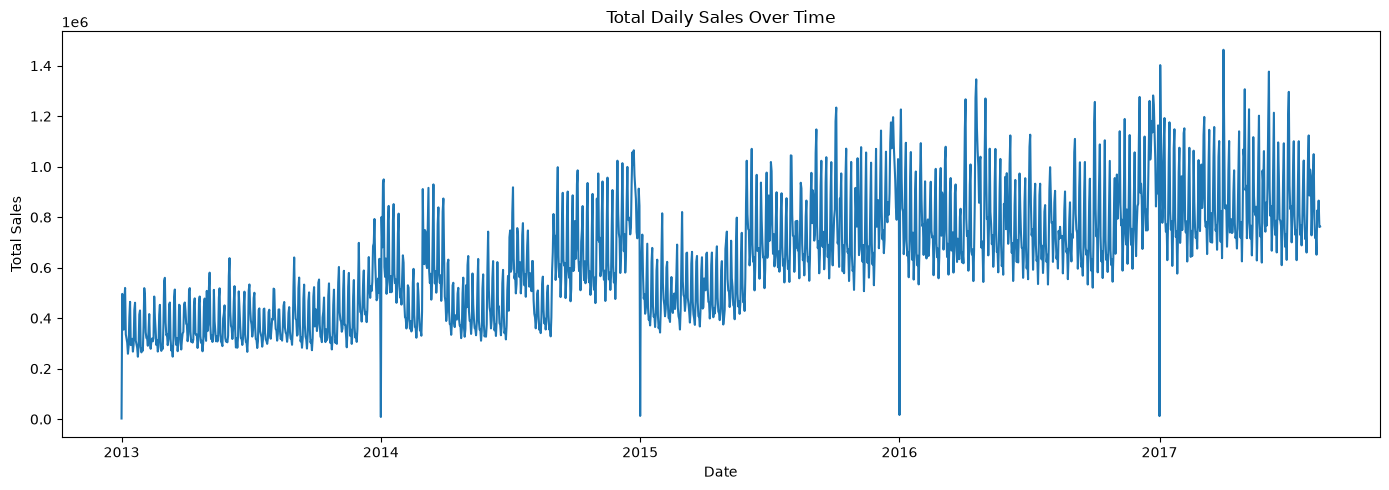

In [31]:
daily_sales = (
    train.groupby("date", as_index=False)["sales"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Insight

The overall daily sales show an increasing trend over the observed period, with sales levels generally higher in later years than in the earlier years.

The series also shows strong day-to-day variability and recurring patterns over time, suggesting the presence of temporal seasonality.

Several dates show very low or zero total sales, which is consistent with the high proportion of zero-sales observations identified during data validation. These observations are retained because they may represent meaningful demand patterns.

### 2. Overall Sales Trend with 7-Day Rolling Average

A 7-day rolling average is used to smooth daily fluctuations and provide a clearer view of the underlying sales trend.

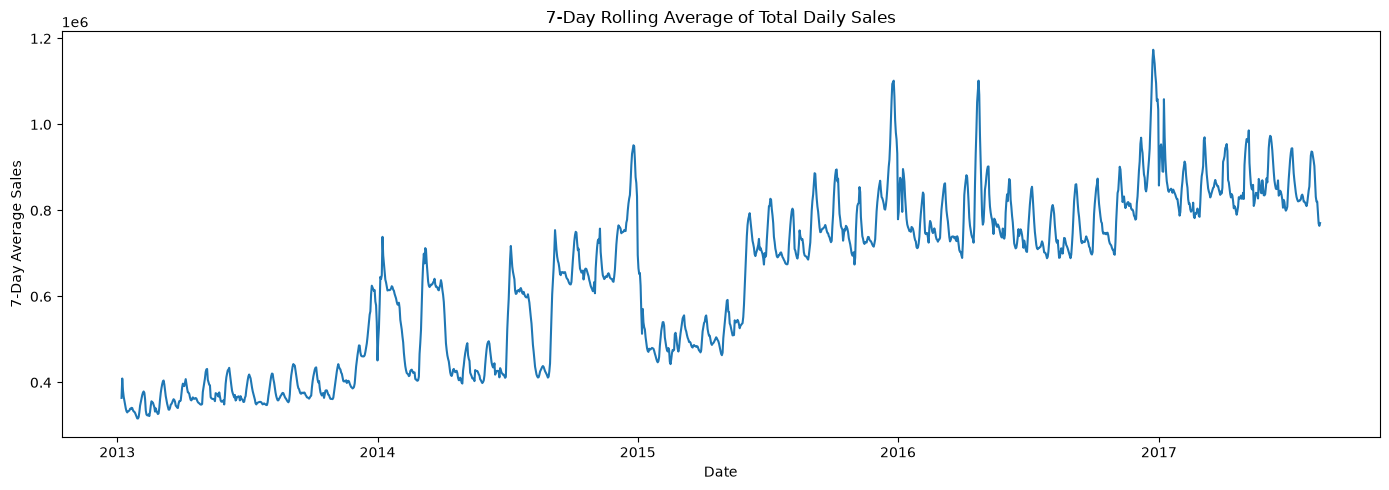

In [32]:
daily_sales["rolling_7d"] = (
    daily_sales["sales"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["rolling_7d"]
)

plt.title("7-Day Rolling Average of Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("7-Day Average Sales")

plt.tight_layout()
plt.show()

### Insight

The 7-day rolling average shows an overall upward trend in sales over the observed period.

Sales levels are generally higher in 2016 and 2017 compared with the earlier years. The series also contains recurring fluctuations, suggesting that temporal patterns and seasonality may influence demand.

A noticeable decline occurs during part of 2015, followed by a recovery and a higher sales level in the later period.

### 3. Top 10 Product Families by Total Sales

We aggregate total sales by product family to identify the product categories that contribute most to overall demand.

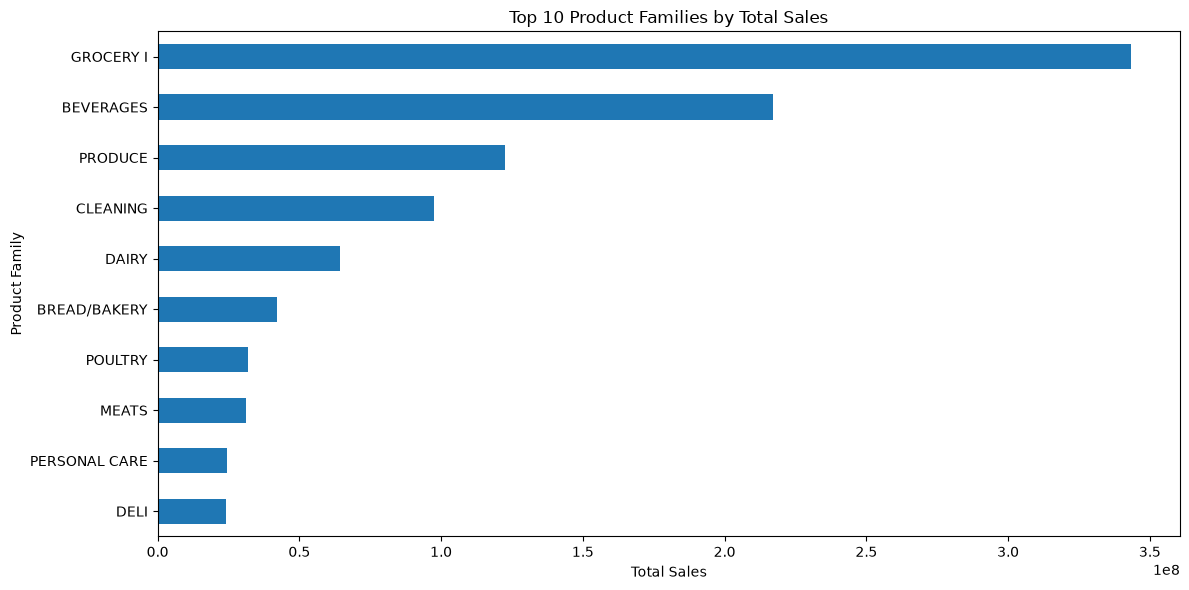

In [33]:
family_sales = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

top_10_families = family_sales.head(10)

plt.figure(figsize=(12, 6))

top_10_families.sort_values().plot(kind="barh")

plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Family")

plt.tight_layout()
plt.show()

### Insight

GROCERY I has the highest total sales among all product families, followed by BEVERAGES and PRODUCE.

The difference between the top product family and the others is substantial, indicating that demand is not evenly distributed across product families.

This suggests that product family should be considered as an important feature when building the demand forecasting model.

### 4. Sales by Promotion Status

We compare total sales on days with and without promotions to examine whether promotional activity is associated with higher demand.

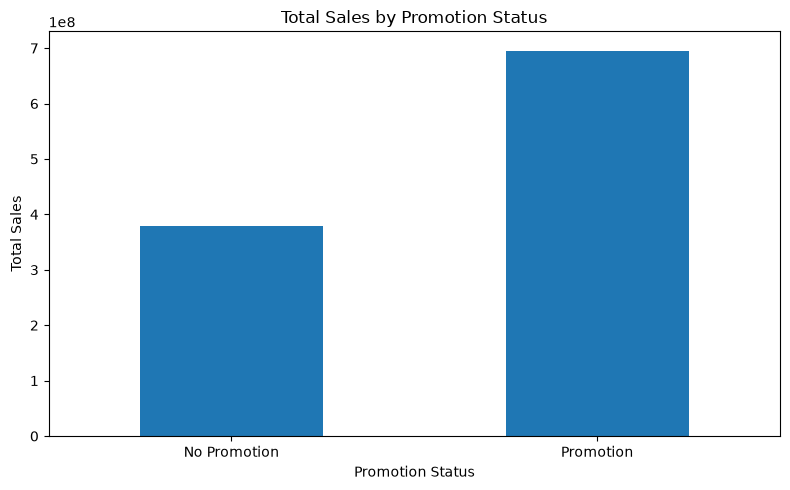

In [34]:
promotion_sales = (
    train.groupby(train["onpromotion"] > 0)["sales"]
    .sum()
)

promotion_sales.index = ["No Promotion", "Promotion"]

plt.figure(figsize=(8, 5))

promotion_sales.plot(kind="bar")

plt.title("Total Sales by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Promotion Sales Validation

Total sales are higher for observations with promotions. However, total sales alone may be affected by the different number of observations in each group.

Therefore, we compare the average sales per observation to better understand the relationship between promotion activity and demand.

In [35]:
promotion_summary = (
    train.groupby(train["onpromotion"] > 0)["sales"]
    .agg(["count", "mean", "median", "sum"])
)

promotion_summary.index = ["No Promotion", "Promotion"]

display(promotion_summary)

,count,mean,median,sum
No Promotion,2389559,158.246681,3.0,3.781398e+08
Promotion,611329,1137.693730,373.0,6.955052e+08


In [36]:
no_promo_mean = promotion_summary.loc["No Promotion", "mean"]
promo_mean = promotion_summary.loc["Promotion", "mean"]

percentage_difference = (
    (promo_mean - no_promo_mean) / no_promo_mean
) * 100

print(
    "Average sales difference:",
    round(percentage_difference, 2),
    "%"
)

Average sales difference: 618.94 %


### Insight

Observations with promotions have substantially higher average sales than observations without promotions.

The average sales are 1,137.69 for promoted observations compared with 158.25 for non-promoted observations, representing a difference of approximately 618.94%.

This strong association suggests that promotion activity may be an important predictive feature for demand forecasting. However, this analysis does not establish a causal relationship between promotions and sales.

### 5. Average Sales by Month

We examine the average sales across months to identify recurring monthly patterns and potential seasonal effects in demand.

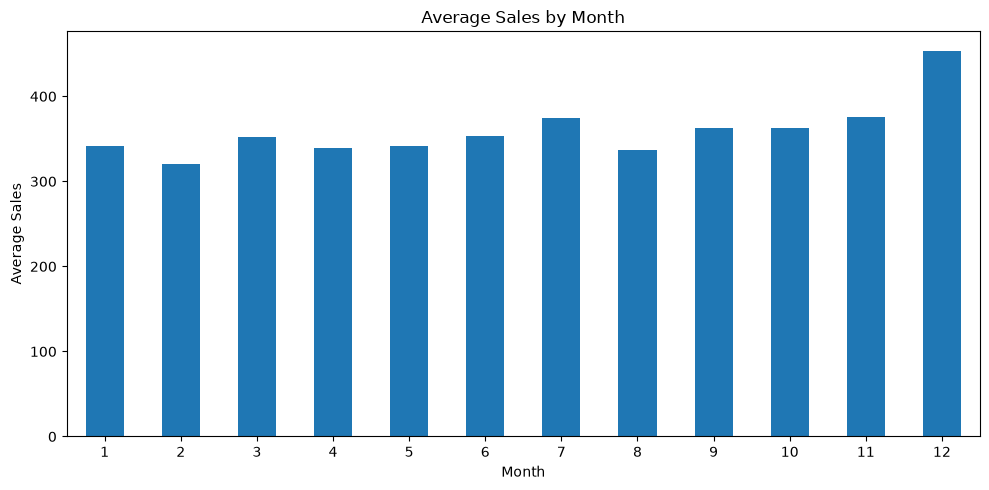

In [37]:
monthly_sales = (
    train.groupby(train["date"].dt.month)["sales"]
    .mean()
)

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Average sales vary across months, indicating a recurring monthly pattern in demand.

December has the highest average sales, while February has the lowest. Although the differences between most months are moderate, the monthly variation suggests that month-related seasonal features may be useful for demand forecasting.